# Spatial Omics Analysis

Inspried by {cite:p}`MarrahiNipmap2023,turosChrysalisDecodingTissue2024,cell2location`, we showcase here how archetypal analysis can be used to model the diversity in spatial niches.

## Packages

To run this notebook, install ParTIpy with the tutorial extras: `pip install partipy[extra]`.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from pathlib import Path
import requests
import zipfile

import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq
import plotnine as pn
import decoupler as dc

import partipy as pt

## Data

Here we will use 10X Xenium data from post-mortem spinal cord samples from chronic acitve and chronic inactive multiple sclerosis lesions as well as control samples {cite:p}`Kukanja2024`. Do we find spatial niches that are enriched in multiple sclerosis samples?

In [2]:
import os
from pathlib import Path
import h5py

path = f"/scratch/pawsey1172/sweng/VisHD/1.integrate_raw_cell/tumour.h5ad"
_orig_asstr = h5py.Dataset.asstr
h5py.Dataset.asstr = lambda self, encoding="utf-8", errors="surrogateescape": _orig_asstr(self, encoding=encoding, errors=errors)

adata = sc.read_h5ad(path)

outdir = Path(f"/scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype")
outdir.mkdir(parents=True, exist_ok=True)

png_dir = outdir / "png"
png_dir.mkdir(parents=True, exist_ok=True)

png_dir
adata

AnnData object with n_obs × n_vars = 122373 × 18132
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'SR_Cluster', 'cell_area', 'nucleus_area', 'n_spatial_neighbours', 'is_artefact', 'slide', 'x_centroid', 'y_centroid', 'AR', 'Inflammation', 'NE1', 'NE2', 'Cycling', 'Glycolysis', 'pearsongraph_res.0.8', 'seurat_clusters', 'pearson_clusters', 'cell_ID', 'pearsonbatchgraph_res.0.8', 'pearson_clusters_batch', 'tumour_score', 'normal_score', 'primary_expr_frac', 'secondary_expr_frac', 'qc_label', 'celltype_annotation', 'celltype_confidence', 'celltype_score_raw', 'celltype_runner_up', 'annotation_source', 'cluster_qc_low_frac', 'tumour_anno', 'category'
    var: 'highly_variable'
    obsm: 'X_pearsonbatchpca', 'X_pearsonbatchumap', 'X_pearsonpca', 'X_pearsonumap', 'spatial'
    layers: 'counts'

In [17]:
collisions = [c for c in adata.obs.columns if c in adata.var_names]
adata.obs.rename(columns={c: f"{c}_score" for c in collisions}, inplace=True)
print(f"Renamed colliding obs columns -> *_score: {collisions}")

Renamed colliding obs columns -> *_score: ['AR']


These cells are already filtered as tumour-annotated cells from the VisHD pipeline (`tumour_anno == "Tumour"`). We inspect the UMI count distribution.

In [4]:
import scipy.sparse as sp

# ── Per-gene mean and variance from SpaNorm log-normalised adata.X ────────────
mat = adata.X
if sp.issparse(mat):
    gene_mean = np.asarray(mat.mean(axis=0)).flatten()
    gene_var  = np.asarray(mat.power(2).mean(axis=0)).flatten() - gene_mean**2
else:
    gene_mean = mat.mean(axis=0)
    gene_var  = mat.var(axis=0)

tumour_markers = ["AR", "FOLH1", "KLK2", "KLK3", "KLK4",
                  "TMPRSS2", "NKX3-1", "HOXB13", "TRPM8"]

mv_df = pd.DataFrame({
    "gene": adata.var_names,
    "mean": gene_mean,
    "var":  gene_var,
})
mv_df["group"] = np.where(mv_df["gene"].isin(tumour_markers), "Tumour marker", "Other")
mv_df["label"] = mv_df["gene"].where(mv_df["gene"].isin(tumour_markers), other=None)

marker_df = mv_df[mv_df["group"] == "Tumour marker"]

p_mean_var = (pn.ggplot(mv_df.sort_values("group"), pn.aes(x="mean", y="var"))
 + pn.geom_point(pn.aes(color="group", size="group"), alpha=0.4)
 + pn.geom_point(data=marker_df, color="#D6604D", size=2.5)
 + pn.geom_text(data=marker_df, mapping=pn.aes(label="label"),
                color="#D6604D", size=7, nudge_y=0.05, adjust_text={"expand_text": (1.5, 1.5)})
 + pn.scale_color_manual(values={"Other": "#b3b3b3", "Tumour marker": "#D6604D"})
 + pn.scale_size_manual(values={"Other": 0.4, "Tumour marker": 2.0})
 + pn.scale_x_continuous(trans="log1p")
 + pn.scale_y_continuous(trans="log1p")
 + pn.labs(
     title    = f"Gene mean vs variance in tumours",
     subtitle = f"SpaNorm log-normalised  |  {len(mv_df):,} genes",
     x        = "Mean expression (log1p)",
     y        = "Variance (log1p)",
     color    = None, size = None,
 )
 + pn.theme_bw()
 + pn.theme(legend_position="top", figure_size=(8, 6))
)

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/mean_var.png
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


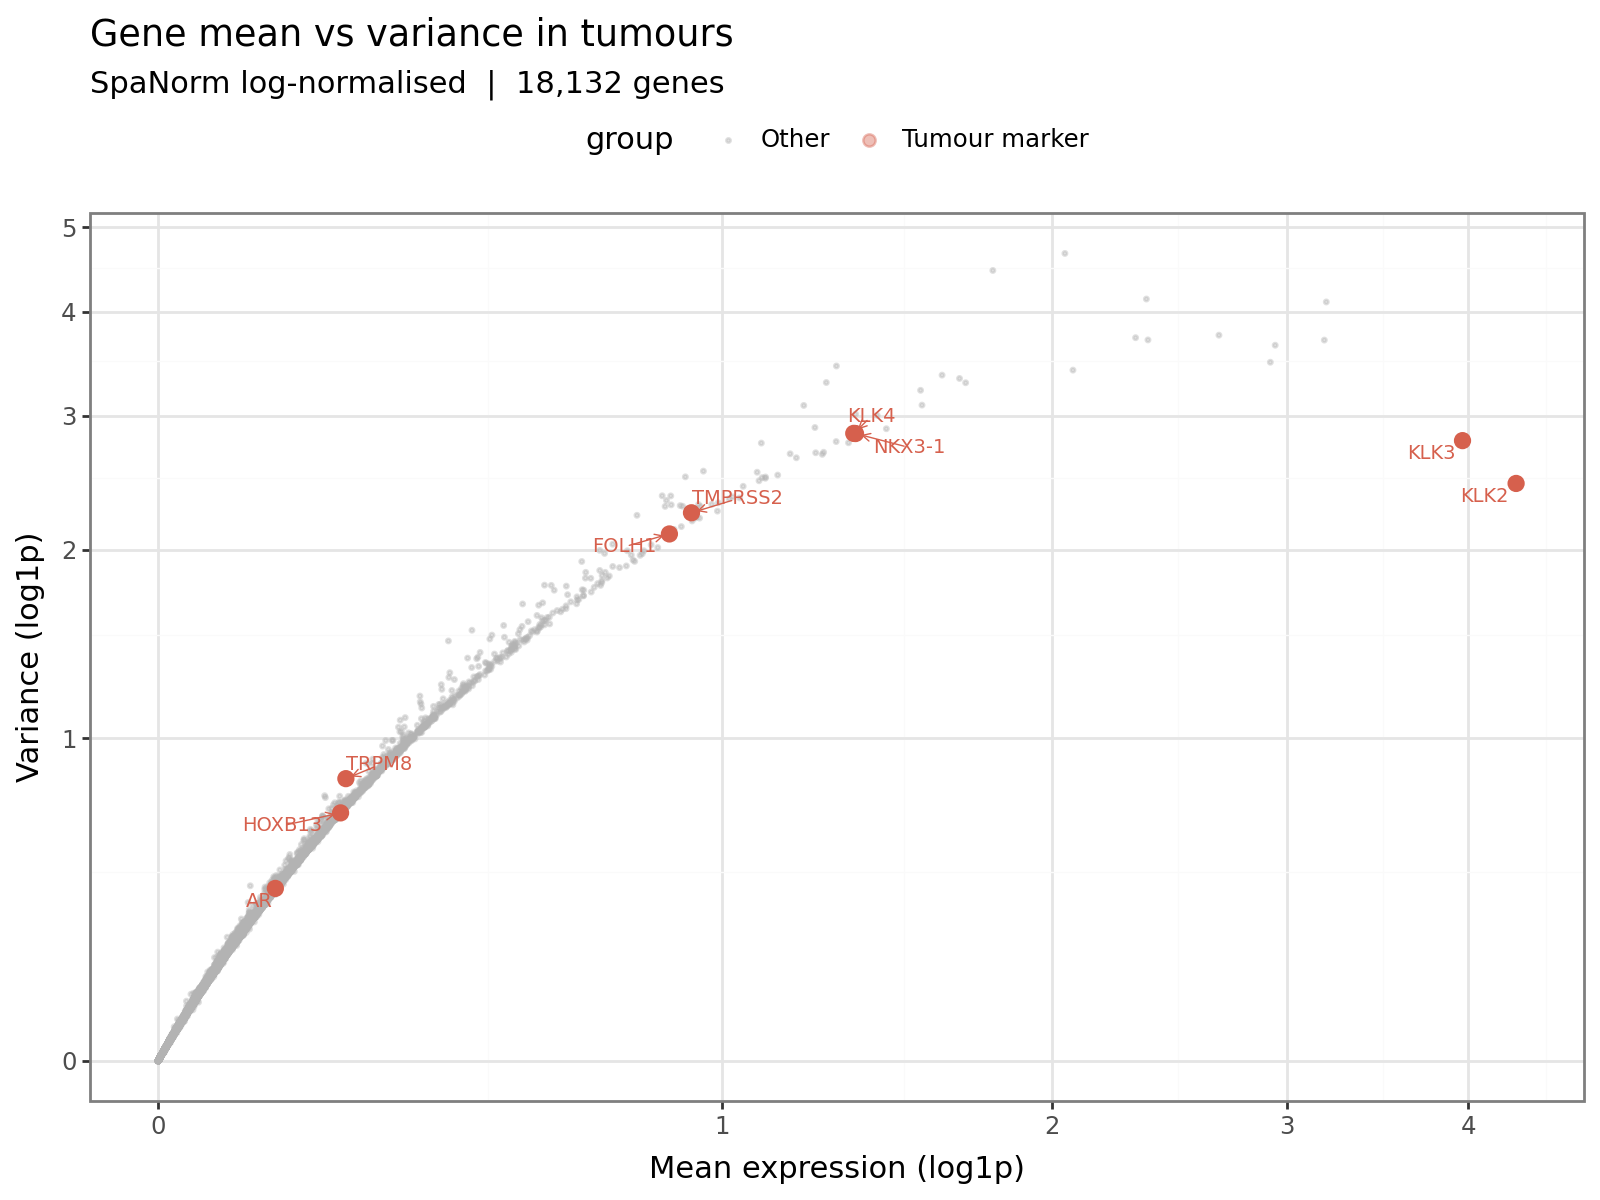

In [5]:
p_mean_var.save(png_dir / "mean_var.png", dpi=150)
p_mean_var

In [6]:
p_ncount = (pn.ggplot(adata.obs) 
 + pn.geom_histogram(pn.aes(x="nCount_Spatial"), bins=100) 
 + pn.scale_x_log10())
 

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/ncount_histogram.png


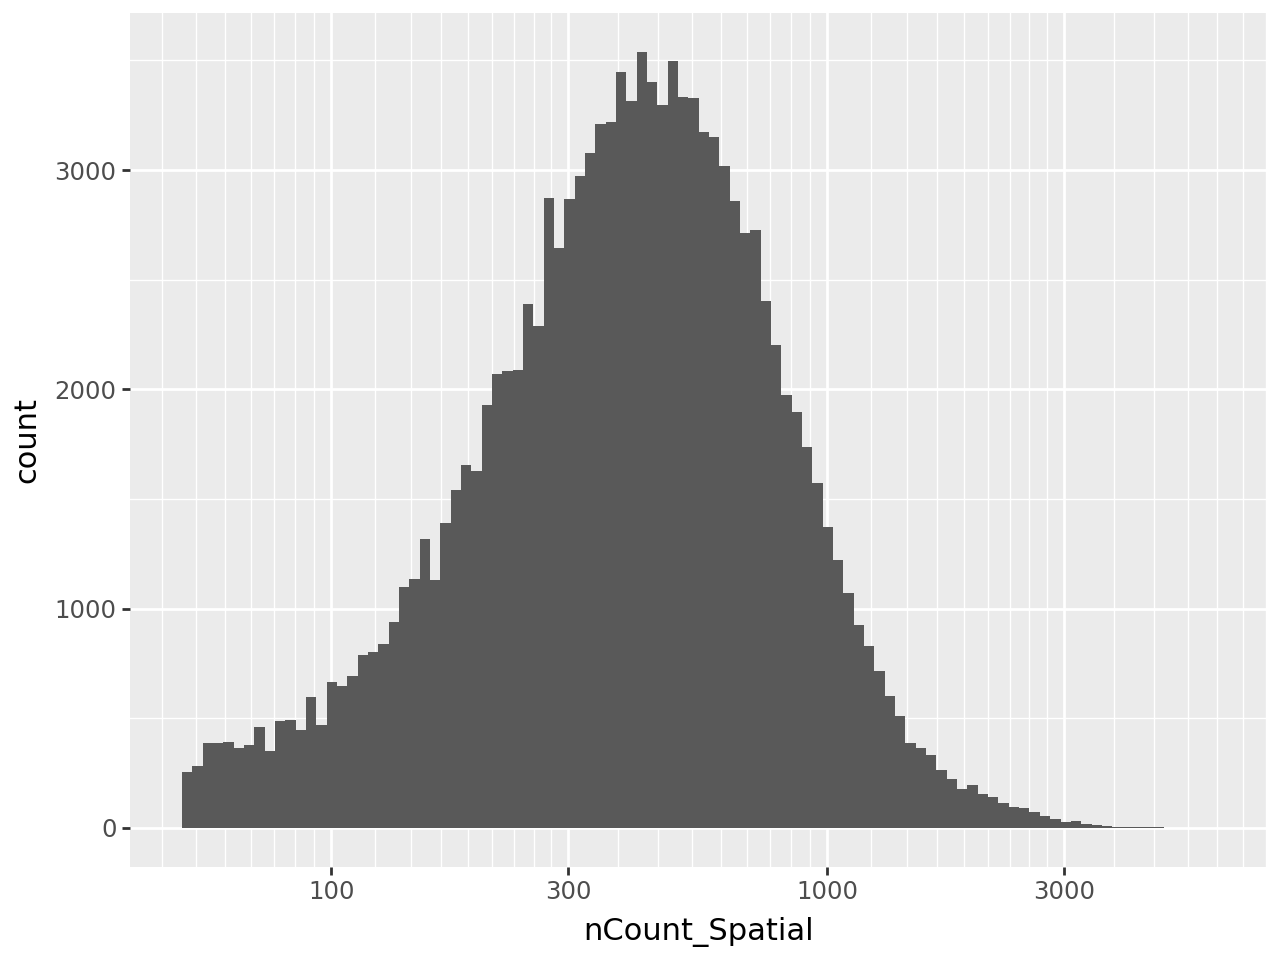

In [7]:
p_ncount.save(png_dir / "ncount_histogram.png", dpi=150)
p_ncount

We will use scanpy for basic preprocessing of the data.

In [9]:
# adata.X is already SpaNorm log-normalised — skip normalize_total and log1p
# Preserve SpaNorm-derived PCA before overwriting with standard PCA
if "X_pearsonbatchpca" in adata.obsm:
      adata.obsm["X_pca"] = adata.obsm["X_pearsonbatchpca"].copy()

# ── Load highly_variable from SVGs (fdr < 0.05) ─────────────────────────────
if "highly_variable" not in adata.var.columns:
    csv_path = Path(f"/scratch/pawsey1172/sweng/VisHD/{sample_id}/tumour/SVGs.csv")
    if csv_path.exists():
        svgs_df = pd.read_csv(csv_path, index_col=0)
        hv_genes = set(svgs_df.loc[svgs_df["svg.fdr"] < 0.05, "symbol"].dropna())
        adata.var["highly_variable"] = adata.var_names.isin(hv_genes)
        print(f"Loaded {adata.var['highly_variable'].sum()} SVGs (fdr<0.05) from {csv_path}")
    else:
        sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000, layer="counts")
        print(f"SVGs.csv not found — computed {adata.var['highly_variable'].sum()} HVGs via scanpy")
else:
    print(f"highly_variable already in adata.var: {adata.var['highly_variable'].sum()} SVGs")
adata.var["highly_variable"] = adata.var["highly_variable"].astype(bool)


highly_variable already in adata.var: 0 SVGs


/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.


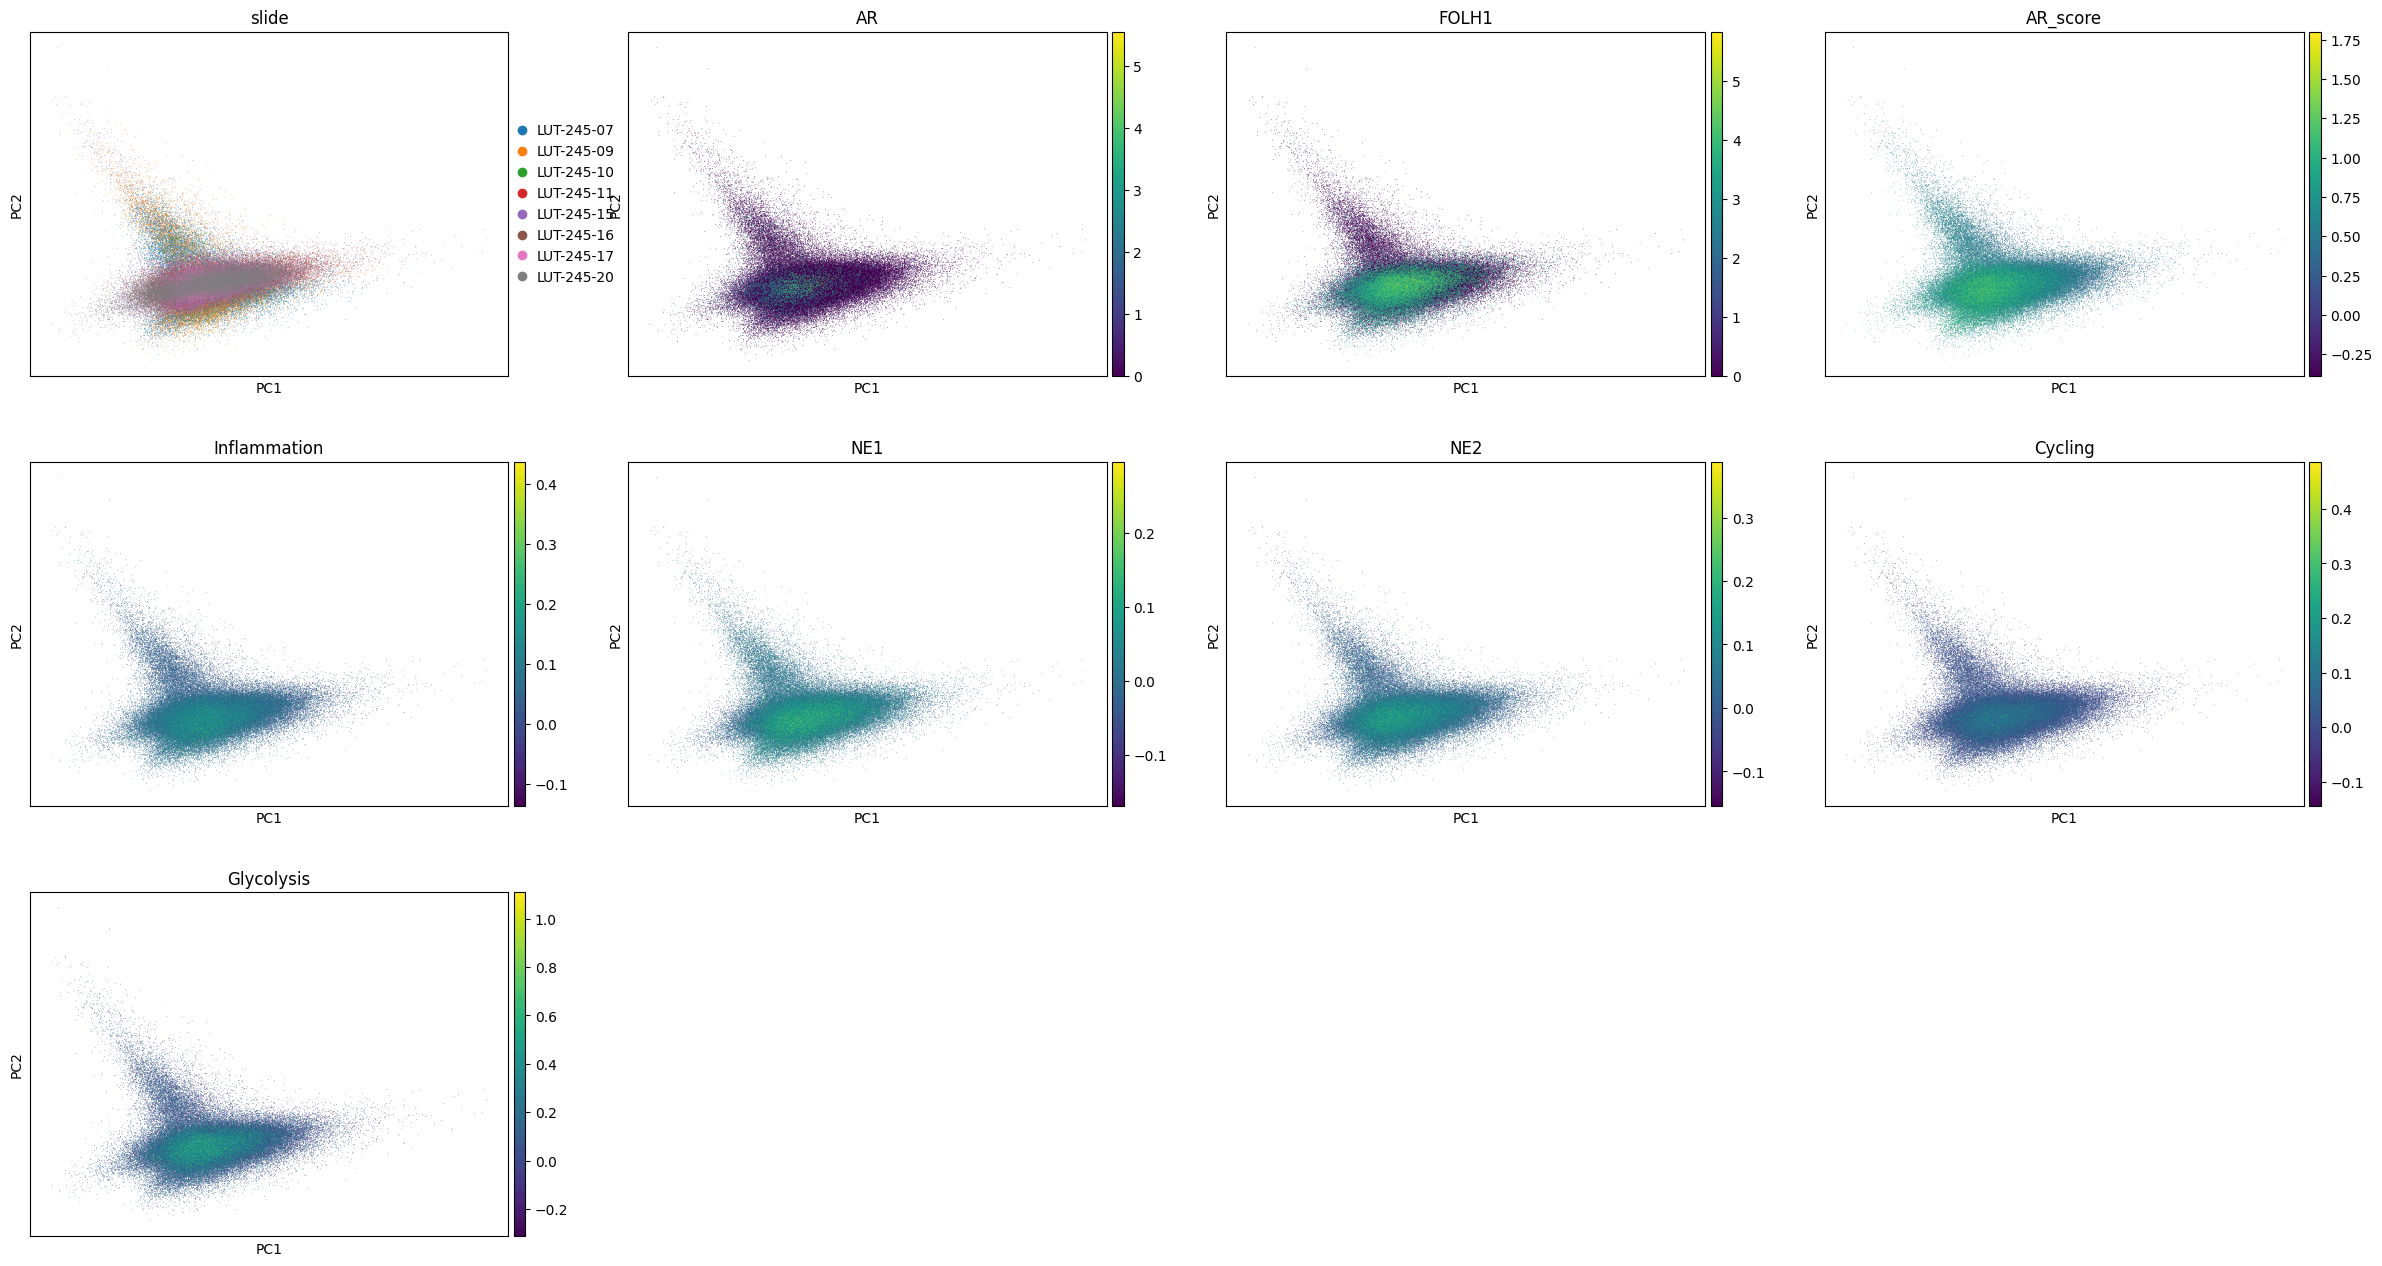

In [18]:
adata.X
adata.layers["z_scaled"] = sc.pp.scale(adata.X, max_value=10, copy=True)

sc.pl.pca_scatter(adata, color=["slide","AR", "FOLH1",
                                "AR_score", "Inflammation",
                                "NE1", "NE2",
                                "Cycling", "Glycolysis"])

To get a niche-level representation of the data we will first spatially smooth the PCA coordinates using Delauny triangulation to define the neighbors of each cell. Stop using spatial information for archetype. 

sq.gr.spatial_neighbors(adata, 
                        spatial_key="spatial",
                        library_key="sample_id",
                        coord_type="generic",
                        delaunay=True, 
                        set_diag=True, 
                        radius=[0, 80])

bandwidth = float(np.quantile(adata.obsp["spatial_distances"].data, 0.5))
adata.obsp["spatial_weights"] = adata.obsp["spatial_distances"].copy()
adata.obsp["spatial_weights"].data = np.exp(-adata.obsp["spatial_distances"].data**2 / (2*bandwidth**2))
adata.obsp["spatial_weights"].setdiag(1.0)
adata.obsm["X_pca_spatial"] = adata.obsp["spatial_weights"] @ adata.obsm["X_pca"]

To get a feeling for the spatial weights, we will visualize the weights for a single cell.


idx = 2_000
adata.obs[f"weights_{idx}"] = adata.obsp["spatial_weights"][idx, :].toarray().flatten()

plot_df = pd.DataFrame({
    "x": adata.obsm["spatial"][:, 0],
    "y": adata.obsm["spatial"][:, 1],
    "c": adata.obs[f"weights_{idx}"]
})

x_coord = adata.obsm["spatial"][idx, 0]
y_coord = adata.obsm["spatial"][idx, 1]

p_spatial_w = (pn.ggplot(plot_df) 
 + pn.geom_point(pn.aes(x="x", y="y", color="c"), size=1.0) 
 + pn.lims(x=[x_coord-500, x_coord+500], y=[y_coord-500, y_coord+500]) 
 + pn.scale_color_cmap(cmap_name="Reds")
 + pn.coord_equal())

p_spatial_w.save(png_dir / "spatial_weights_example.png", dpi=150)
p_spatial_w

To determine the number of principal components to use for fitting the archetypes, we will examine the scree plot from the PCA. The plot indicates that the gain in explained variance becomes negligible beyond the sixth principal component.

In [25]:
# ── Load highly_variable from SVGs (fdr < 0.05) if not already in adata.var ─────
if "highly_variable" not in adata.var.columns:
    csv_path = Path(f"/scratch/pawsey1172/sweng/VisHD/{sample_id}/tumour/SVGs.csv")
    if csv_path.exists():
        svgs_df = pd.read_csv(csv_path, index_col=0)
        hv_genes = set(svgs_df.loc[svgs_df["svg.fdr"] < 0.05, "symbol"].dropna())
        adata.var["highly_variable"] = adata.var_names.isin(hv_genes)
        print(f"Loaded {adata.var['highly_variable'].sum()} SVGs (fdr<0.05) from {csv_path}")
    else:
        sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000, layer="X")
        print(f"SVGs.csv not found — computed {adata.var['highly_variable'].sum()} HVGs via scanpy")
else:
    print(f"highly_variable already in adata.var: {adata.var['highly_variable'].sum()} SVGs")
adata.var["highly_variable"] = adata.var["highly_variable"].astype(bool)


highly_variable already in adata.var: 5000 SVGs


In [24]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000, layer="counts")

In [26]:
%%capture
pt.compute_shuffled_pca(adata, mask_var="highly_variable")

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 3 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/shuffled_pca.png


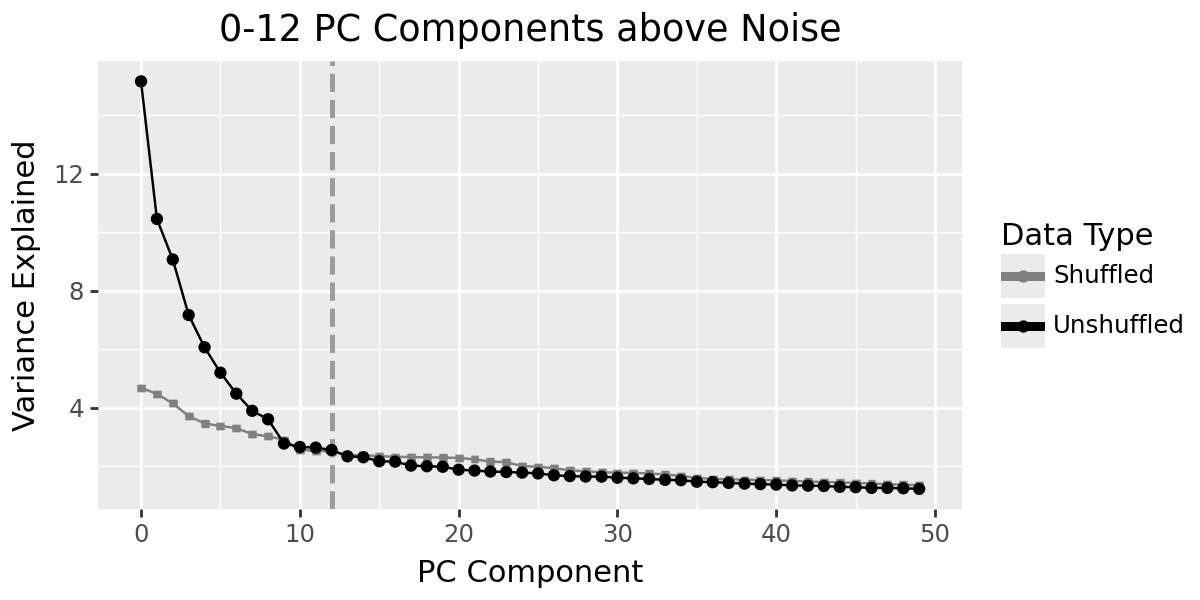

In [27]:
p_shuffled_pca = pt.plot_shuffled_pca(adata)
p_shuffled_pca.save(png_dir / "shuffled_pca.png", dpi=150)
p_shuffled_pca

First we need to determine the number of archetypes. Since we have 600,000 cells here, we will use a coreset fraction of 3% specified by `coreset_fraction=0.03` and `coreset_algorithm="standard"`. Additionally, we need to specify that we want to use the spatially smoothed PCA coordinates, `obsm_key="X_pca_spatial"`.

In [29]:
pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=list(range(1,9)))

We start - as always - by computing the statistics used to determine the number of archetypes.

In [31]:
# takes ~3.5 minutes on my macbook
pt.compute_selection_metrics(adata=adata, 
                             n_archetypes_list=[ 2 ,3 , 4, 5, 6, 7, 8, 9],
                             coreset_algorithm="standard",
                             coreset_fraction=0.1, 
                             n_restarts=2)
p_var_exp = pt.plot_var_explained(adata)
p_ic = pt.plot_IC(adata)

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 3 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/var_explained.png


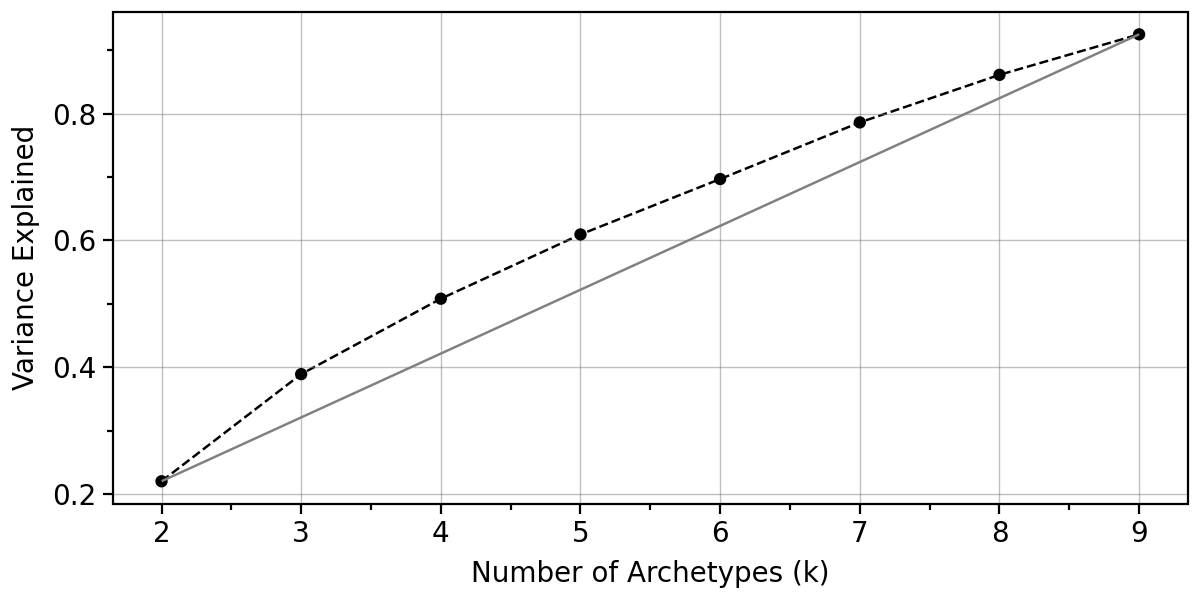

In [32]:
p_var_exp.save(png_dir / "var_explained.png", dpi=150)
p_var_exp

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 3 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/IC.png


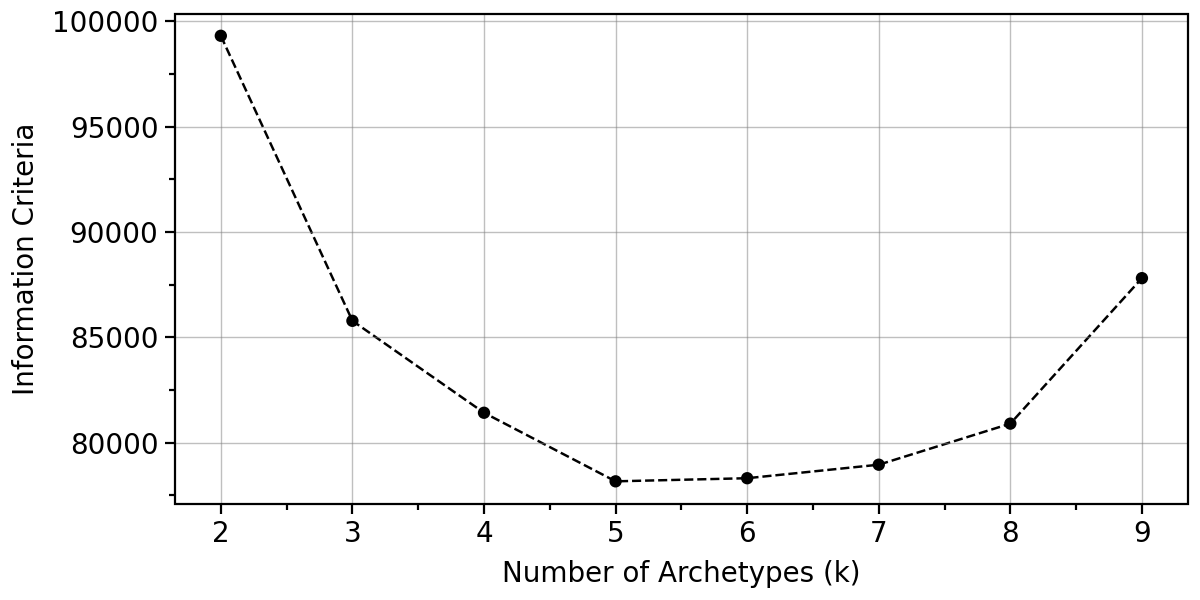

In [33]:
p_ic.save(png_dir / "IC.png", dpi=150)
p_ic

Let us also look at the boostrap variance when using 4-6 archetypes.

In [34]:
# takes ~3.5 minutes on my macbook
pt.compute_bootstrap_variance(adata=adata, 
                              n_bootstrap=20, 
                              n_archetypes_list=[3, 4, 5, 6,7],
                              coreset_algorithm="standard",
                              coreset_fraction=0.1)

Based on the variance-explained, IC, and bootstrap-variance plots, the chosen archetype count for this sample is set per-sample via `n_archetypes_by_sample` (see cell setup).

In [35]:
p_bootstrap_var = pt.plot_bootstrap_variance(adata)

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 3 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/bootstrap_variance.png


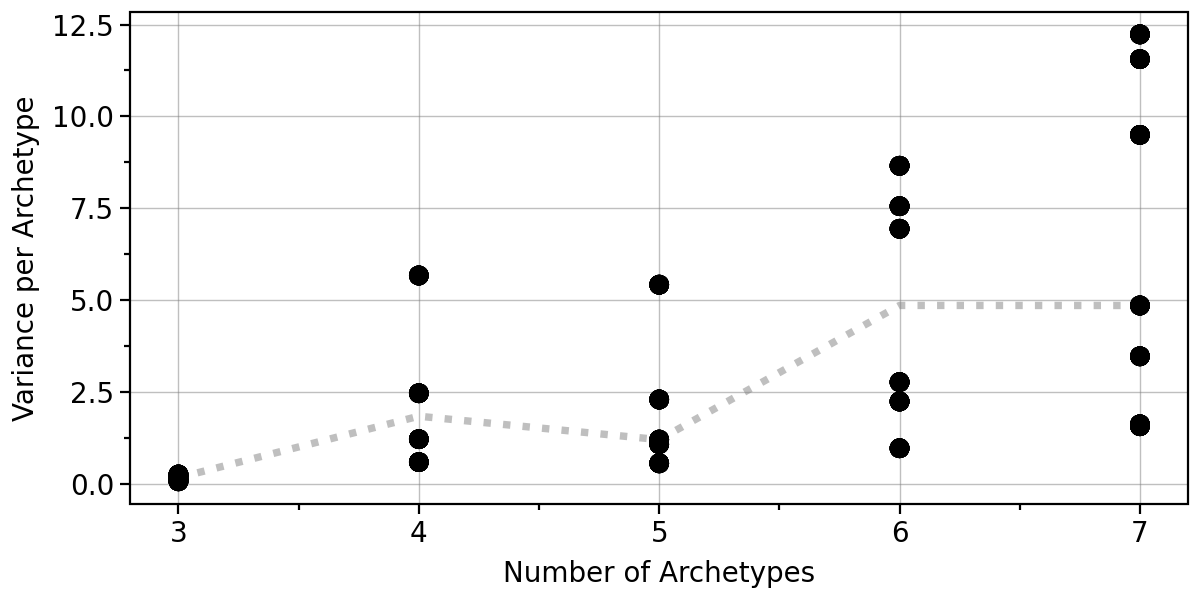

In [36]:
p_bootstrap_var.save(png_dir / "bootstrap_variance.png", dpi=150)
p_bootstrap_var

In [37]:
n_archetypes = 5

We can also visualize the bootstrap results for the chosen `n_archetypes` solution in 2D.

In [38]:
p_bootstrap_2d = pt.plot_bootstrap_2D(adata, result_filters={"n_archetypes": n_archetypes})

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `dict[str, any]` - serialized value may not be as expected [field_name='optim_kwargs', input_value=(), input_type=tuple])


/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/bootstrap_2D.png


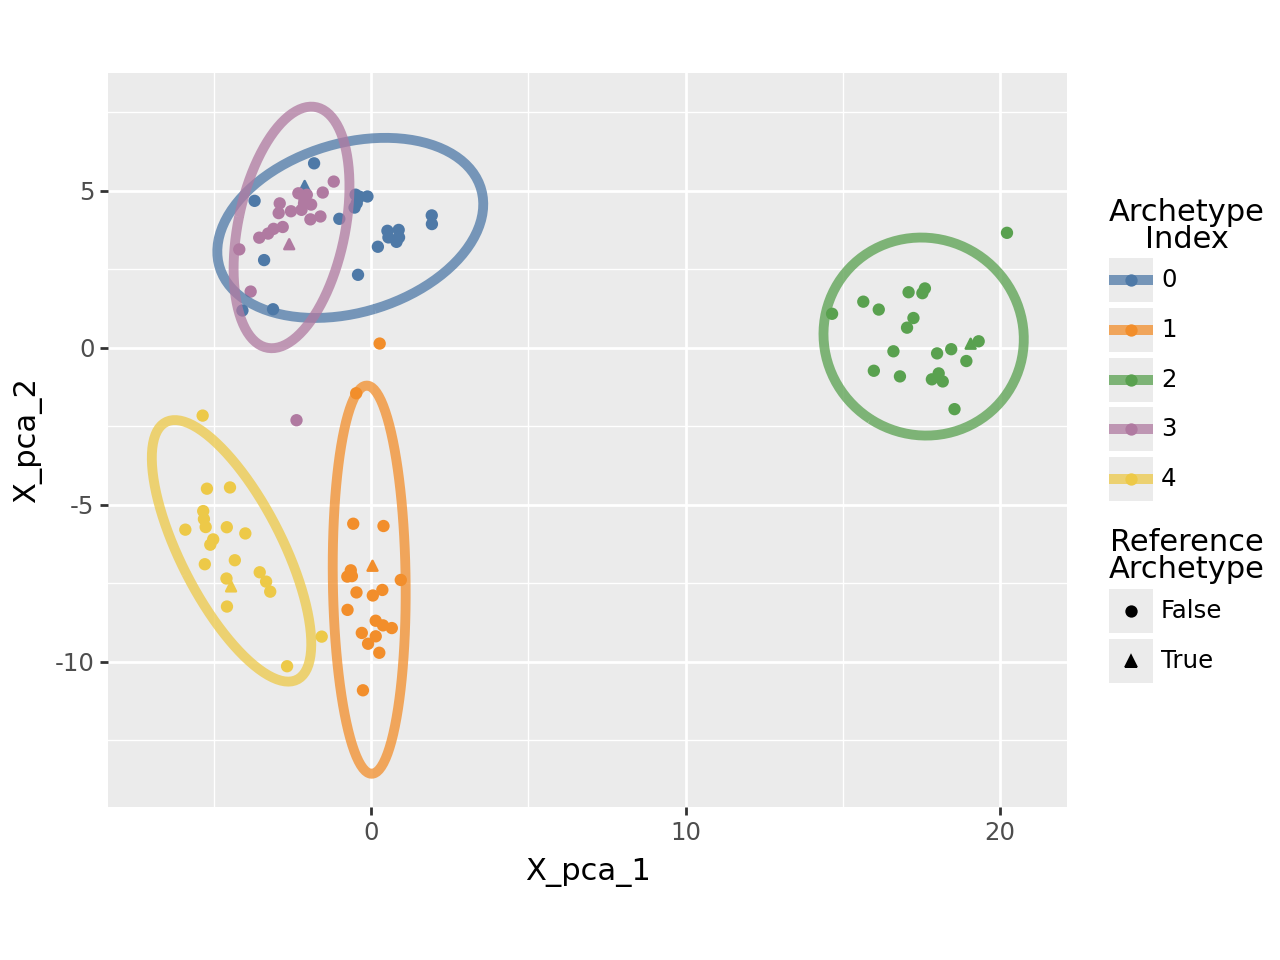

In [39]:
p_bootstrap_2d.save(png_dir / "bootstrap_2D.png", dpi=150)
p_bootstrap_2d

In [40]:
# Keep only the chosen-n_archetypes result so compute_archetypes below
# produces the sole unambiguous downstream result
if "AA_results" in adata.uns:
    adata.uns["AA_results"] = {
        cfg: payload for cfg, payload in adata.uns["AA_results"].items()
        if cfg.n_archetypes != n_archetypes
    }

In [41]:
pt.compute_archetypes(adata, 
                      n_archetypes=n_archetypes, 
                      coreset_algorithm="standard", 
                      coreset_fraction = 0.1, 
                      archetypes_only=False)

We also visualize the archetypes and their bootstrap-derived confidence contours in a 2D PC plot alongside all individual data points (i.e. cells).

In [42]:
p_arch_2d_12 = pt.plot_archetypes_2D(adata, show_contours=True, alpha=0.1, dimensions=[1, 2], result_filters={"n_archetypes": n_archetypes})

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `dict[str, any]` - serialized value may not be as expected [field_name='optim_kwargs', input_value=(), input_type=tuple])


/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/archetypes_2D_dim12.png


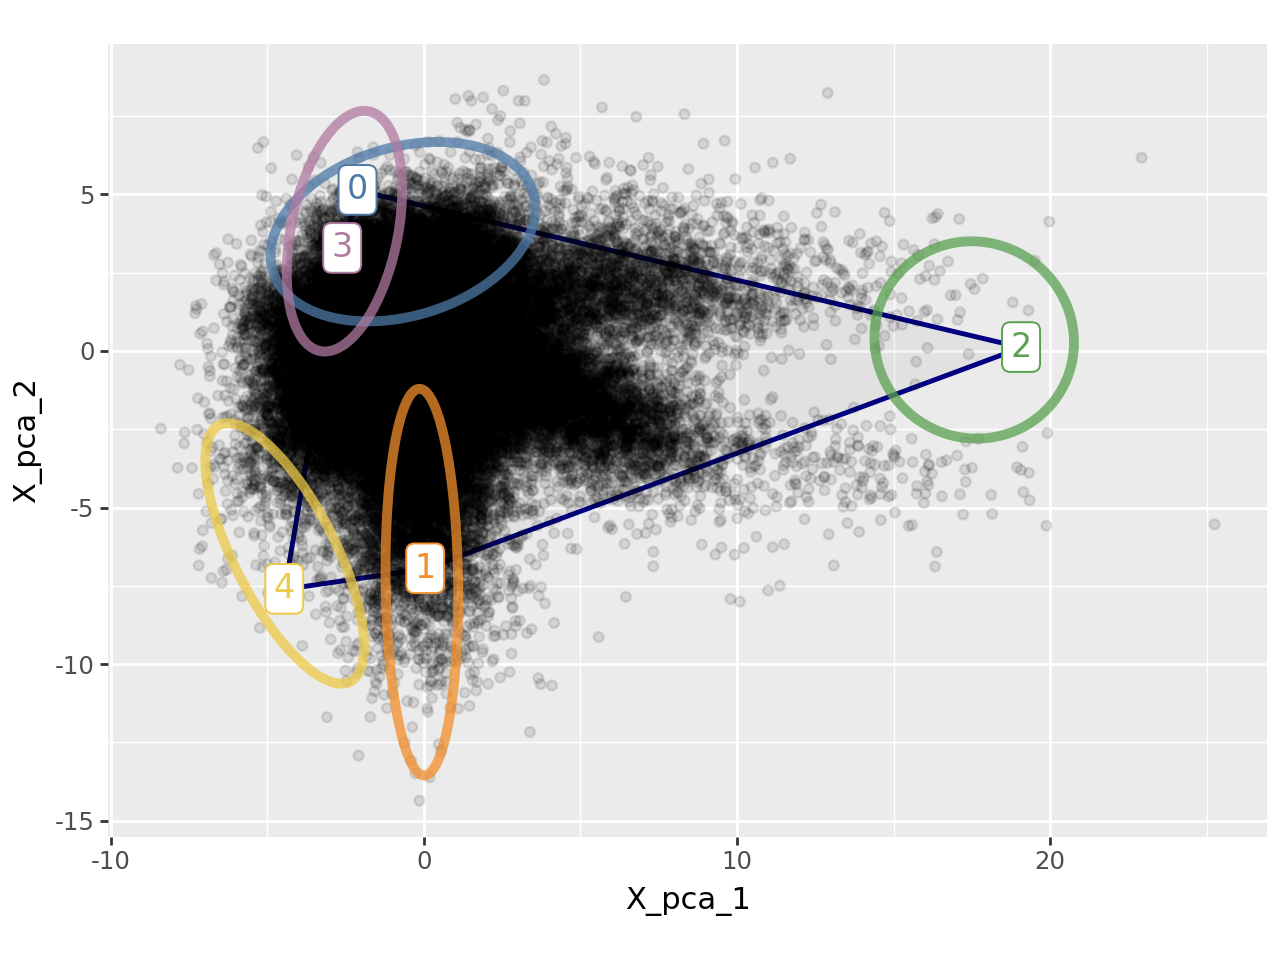

In [43]:
p_arch_2d_12.save(png_dir / "archetypes_2D_dim12.png", dpi=150)
p_arch_2d_12

In [44]:
p_arch_2d_34 = pt.plot_archetypes_2D(adata, show_contours=True, alpha=0.1, dimensions=[3, 4], result_filters={"n_archetypes": n_archetypes})

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `dict[str, any]` - serialized value may not be as expected [field_name='optim_kwargs', input_value=(), input_type=tuple])


/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/archetypes_2D_dim34.png


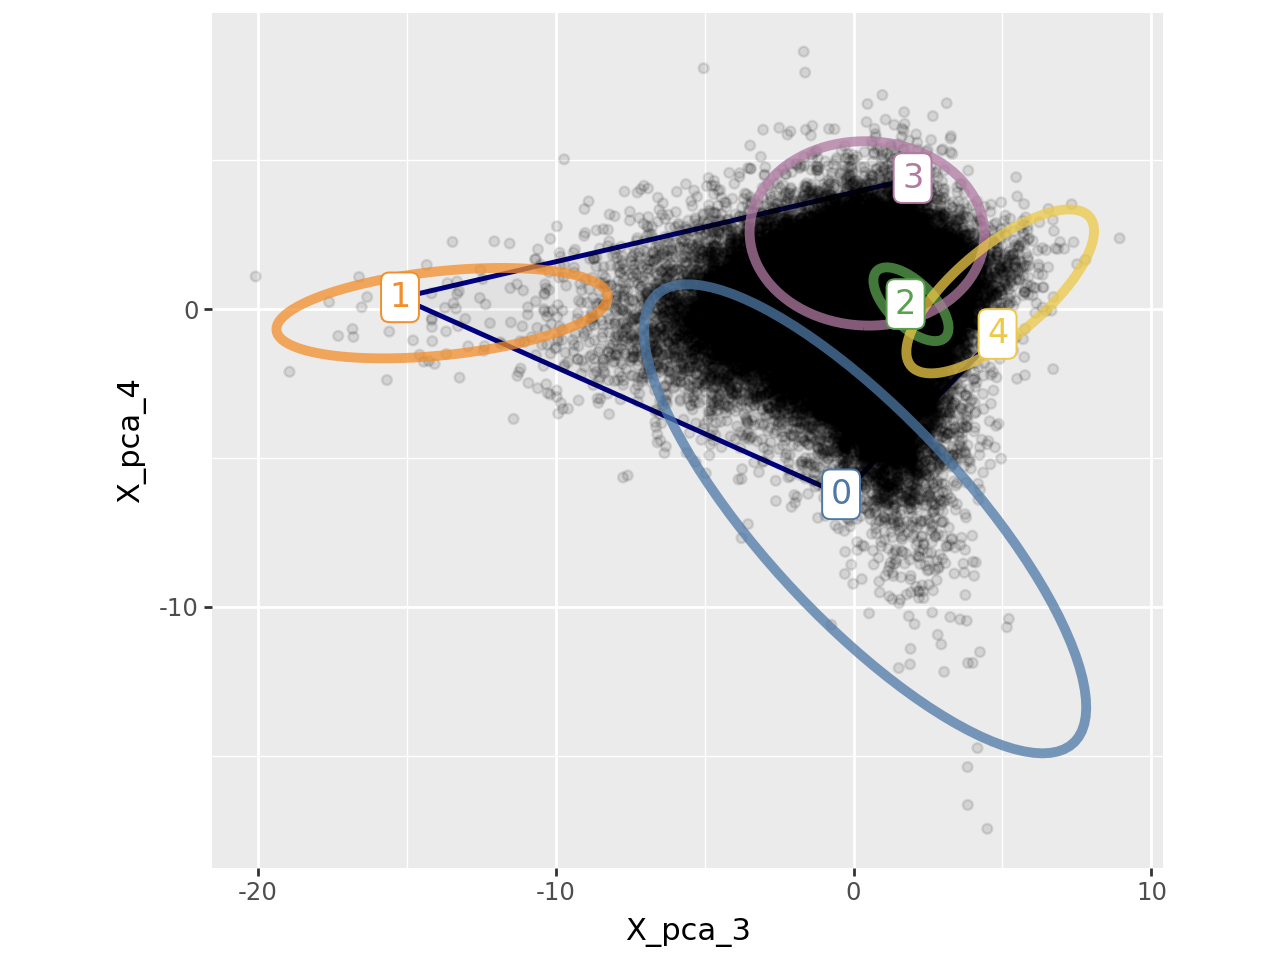

In [45]:
p_arch_2d_34.save(png_dir / "archetypes_2D_dim34.png", dpi=150)
p_arch_2d_34

Now let's find out if we have archetypes that are enriched in particular samples. This can reveal whether certain spatial niches are sample-specific or shared across the cohort.

In [47]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pt.compute_archetype_weights(adata=adata, mode="automatic", result_filters={"n_archetypes": n_archetypes})

category_enrichment = pt.compute_meta_enrichment(adata, meta_col="category", result_filters={"n_archetypes": n_archetypes})

categories = sorted(adata.obs["category"].astype(str).unique())
cat_cmap = plt.get_cmap("Set1", len(categories))
category_colors = {c: mcolors.to_hex(cat_cmap(i)) for i, c in enumerate(categories)}


p_cat_enrich = pt.barplot_meta_enrichment(category_enrichment, meta="Category", color_map=category_colors)

Applied length scale is 5.08.


/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/meta_enrichment_category.png


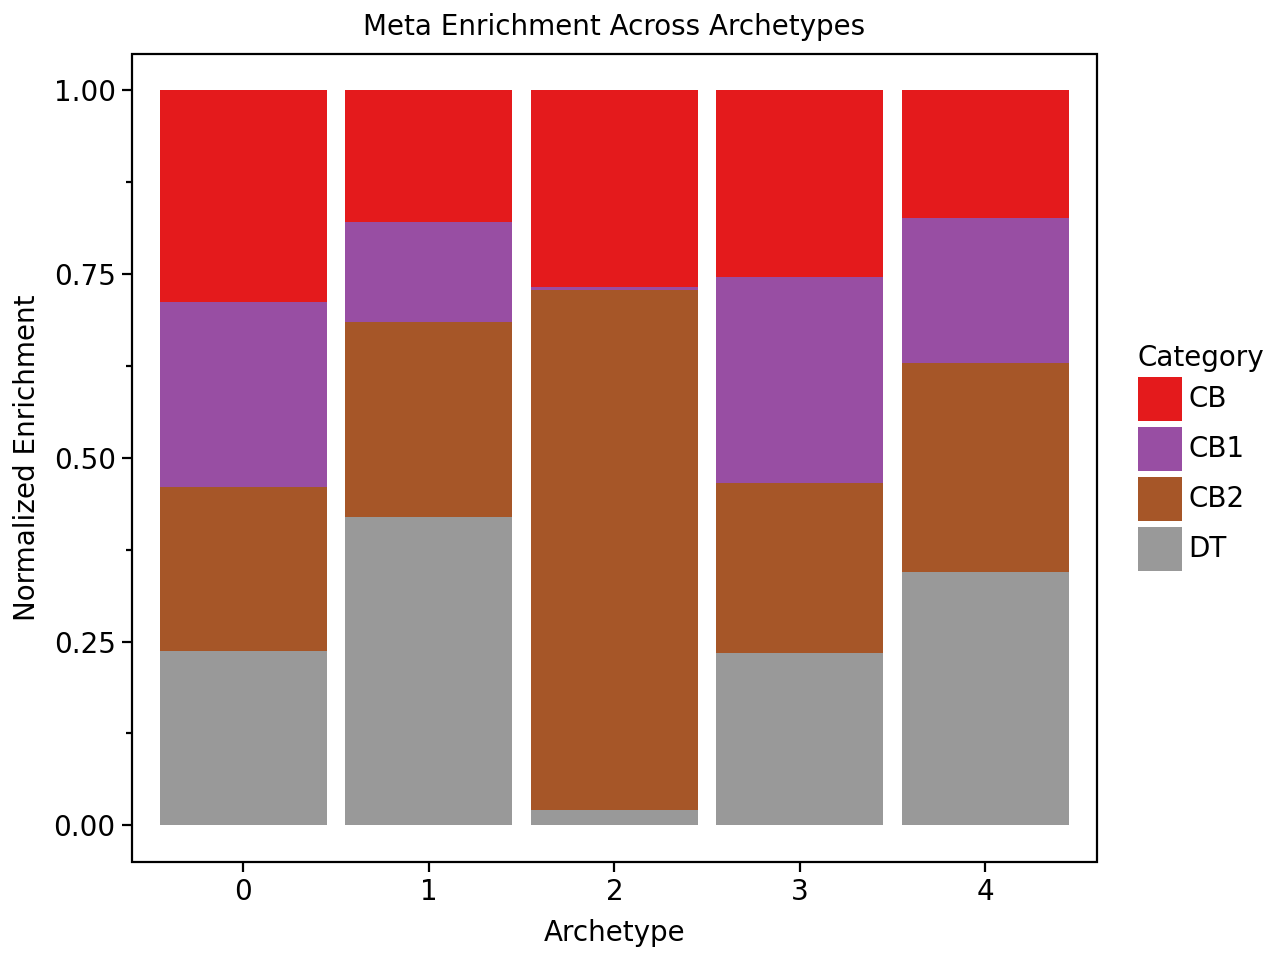

In [48]:
p_cat_enrich.save(png_dir / "meta_enrichment_category.png", dpi=150)
p_cat_enrich

We also check which BANKSY-derived tumour clusters are enriched in the different spatial niches defined by the archetypes.

In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cluster_enrichment = pt.compute_meta_enrichment(adata, meta_col="pearson_clusters_batch", result_filters={"n_archetypes": n_archetypes})

clusters = sorted(adata.obs["pearson_clusters_batch"].astype(str).unique(), key=lambda x: int(x))
cmap = plt.get_cmap("tab20", len(clusters))
cluster_colors = {c: mcolors.to_hex(cmap(i)) for i, c in enumerate(clusters)}

p_cluster_enrich = pt.barplot_meta_enrichment(cluster_enrichment, meta="Pearson Cluster", color_map=cluster_colors)

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/meta_enrichment_pearson_clusters.png


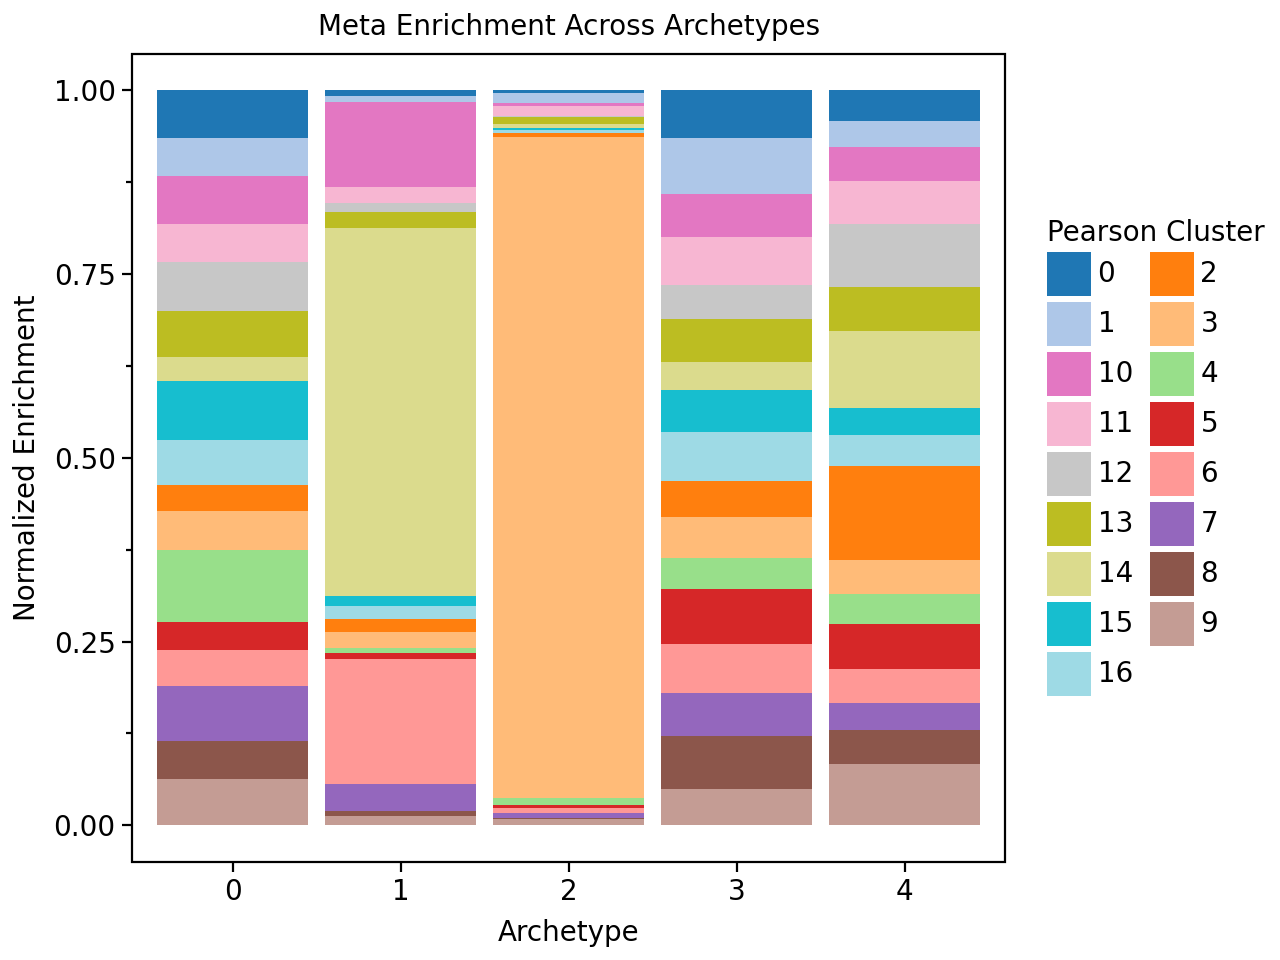

In [50]:
p_cluster_enrich.save(png_dir / "meta_enrichment_pearson_clusters.png", dpi=150)
p_cluster_enrich

Apart from looking at cluster enrichment we can also directly look at the genes most associated with each archetype.

In [53]:
archetype_expression = pt.compute_archetype_expression(adata=adata, layer="z_scaled", result_filters={"n_archetypes": n_archetypes})

Instead of looking at the genes directly, we can also perform pathway enrichment analysis, which reveals that the archetype enriched in chronic inactive samples exhibits high levels of hypoxia. However, since only 266 were profiled here, prior knowledge enrichment analysis is not very reliable here!

In [54]:
net = dc.op.progeny()

acts_ulm_est, acts_ulm_est_p = dc.mt.ulm(data=archetype_expression,
                                         net=net,
                                         verbose=False)

top_processes = pt.extract_enriched_processes(est=acts_ulm_est, 
                                              pval=acts_ulm_est_p, 
                                              order="desc", 
                                              n=3,
                                              p_threshold=0.05)

for arch_idx, df in top_processes.items():
    print(f"\n--- Archetype {arch_idx} ---")
    print(df)




--- Archetype 0 ---
  Process         0         1         2         3         4  specificity
0    TGFb  8.174432 -0.239273 -3.681409  4.770783  1.524789     3.403649
1    VEGF  4.149818  9.103405  1.274958  5.230111  6.063033    -4.953587
2    PI3K  1.979455  4.296670 -5.669199 -4.381077  8.895702    -6.916247

--- Archetype 1 ---
    Process          0          1         2          3         4  specificity
0  JAK-STAT  -6.116579  30.784096  6.591259  -4.996416 -0.647832    24.192836
1      TNFa -15.825918  23.745757 -3.229206 -13.380605  2.790819    20.954938
2      NFkB -23.693344  22.824387 -3.975517 -19.779615  1.784193    21.040194

--- Archetype 2 ---
    Process          0          1          2         3          4  specificity
0  Androgen  -4.456224   4.575035  15.251288 -5.960310  26.154700   -10.903411
1  JAK-STAT  -6.116579  30.784096   6.591259 -4.996416  -0.647832   -24.192836
2   Hypoxia -15.659364   0.896075   3.222797 -8.430641   3.114986     0.107811

--- Archetype 3 

Finally, since we have spatial data let's check where the most sample-variable archetype is located in tissue across all samples.

In [56]:
cell_weights = pt.compute_archetype_weights(adata=adata, mode="automatic", save_to_anndata=False, result_filters={"n_archetypes": n_archetypes})

n_archetypes_out = cell_weights.shape[1]
for i in range(n_archetypes_out):
    adata.obs[f"weights_archetype_{i}"] = cell_weights[:, i].copy()

arch_cols = [f"weights_archetype_{i}" for i in range(n_archetypes_out)]

# Spatial plot
adata.obs["x_spatial"] = adata.obsm["spatial"][:, 0]
adata.obs["y_spatial"] = adata.obsm["spatial"][:, 1]

plot_spatial = adata.obs[["x_spatial", "y_spatial"] + arch_cols].melt(
    id_vars=["x_spatial", "y_spatial"], var_name="archetype", value_name="weight"
)
plot_spatial["archetype"] = plot_spatial["archetype"].str.replace("weights_archetype_", "Archetype ")

p_spatial = (pn.ggplot(plot_spatial)
     + pn.geom_point(pn.aes(x="x_spatial", y="y_spatial", color="weight"), size=0.05)
     + pn.facet_wrap("archetype~slide", ncol=5)
     + pn.scale_color_cmap("viridis")
     + pn.coord_equal()
     + pn.theme(figure_size=(12, 12)))

# UMAP plot
adata.obs["umap_1"] = adata.obsm["X_pearsonbatchumap"][:, 0]
adata.obs["umap_2"] = adata.obsm["X_pearsonbatchumap"][:, 1]

plot_umap = adata.obs[["umap_1", "umap_2"] + arch_cols].melt(
    id_vars=["umap_1", "umap_2"], var_name="archetype", value_name="weight"
)
plot_umap["archetype"] = plot_umap["archetype"].str.replace("weights_archetype_", "Archetype ")

p_umap = (pn.ggplot(plot_umap)
     + pn.geom_point(pn.aes(x="umap_1", y="umap_2", color="weight"), size=0.05)
     + pn.facet_wrap("archetype", ncol=3)
     + pn.scale_color_cmap("viridis")
     + pn.theme(figure_size=(12, 12)))


Applied length scale is 5.08.


/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 12 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/archetype_weights_spatial.png
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 73415 rows containing missing values.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 73415 rows containing missing values.


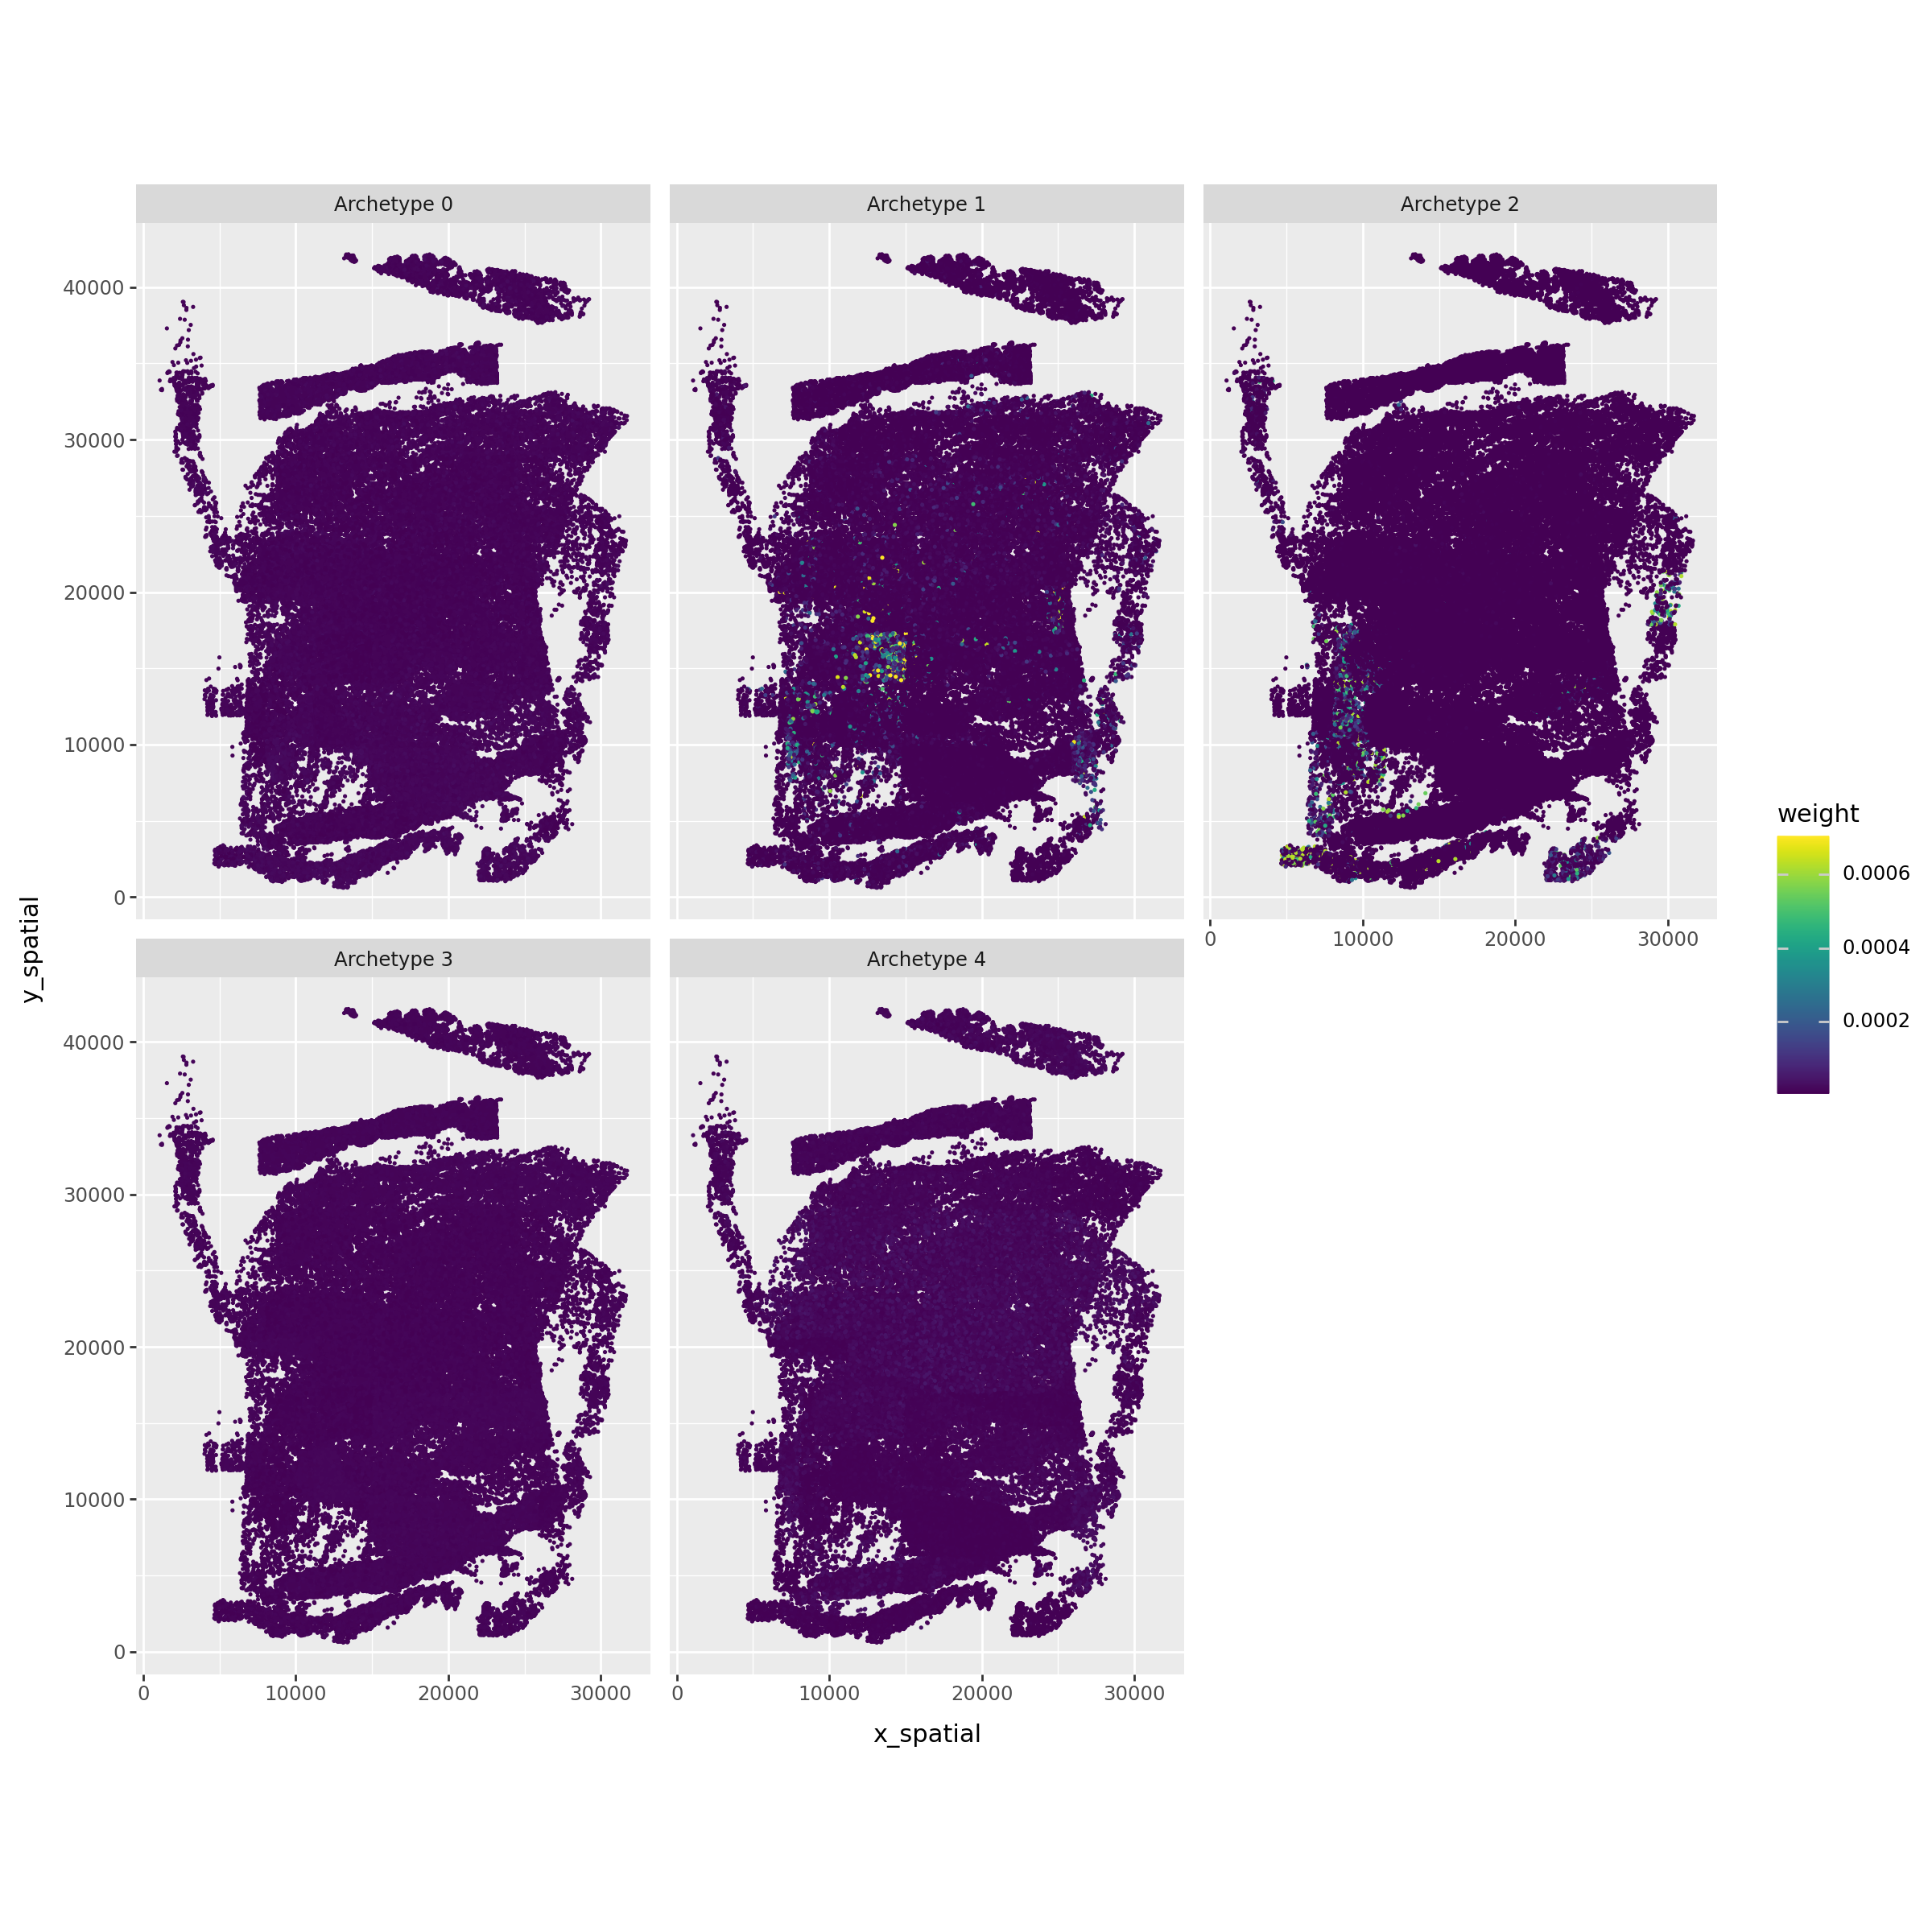

In [57]:
p_spatial.save(png_dir / "archetype_weights_spatial.png", dpi=150)
p_spatial

/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 12 in image.
/scratch/pawsey1172/sweng/conda/envs/partipy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype/png/archetype_weights_umap.png


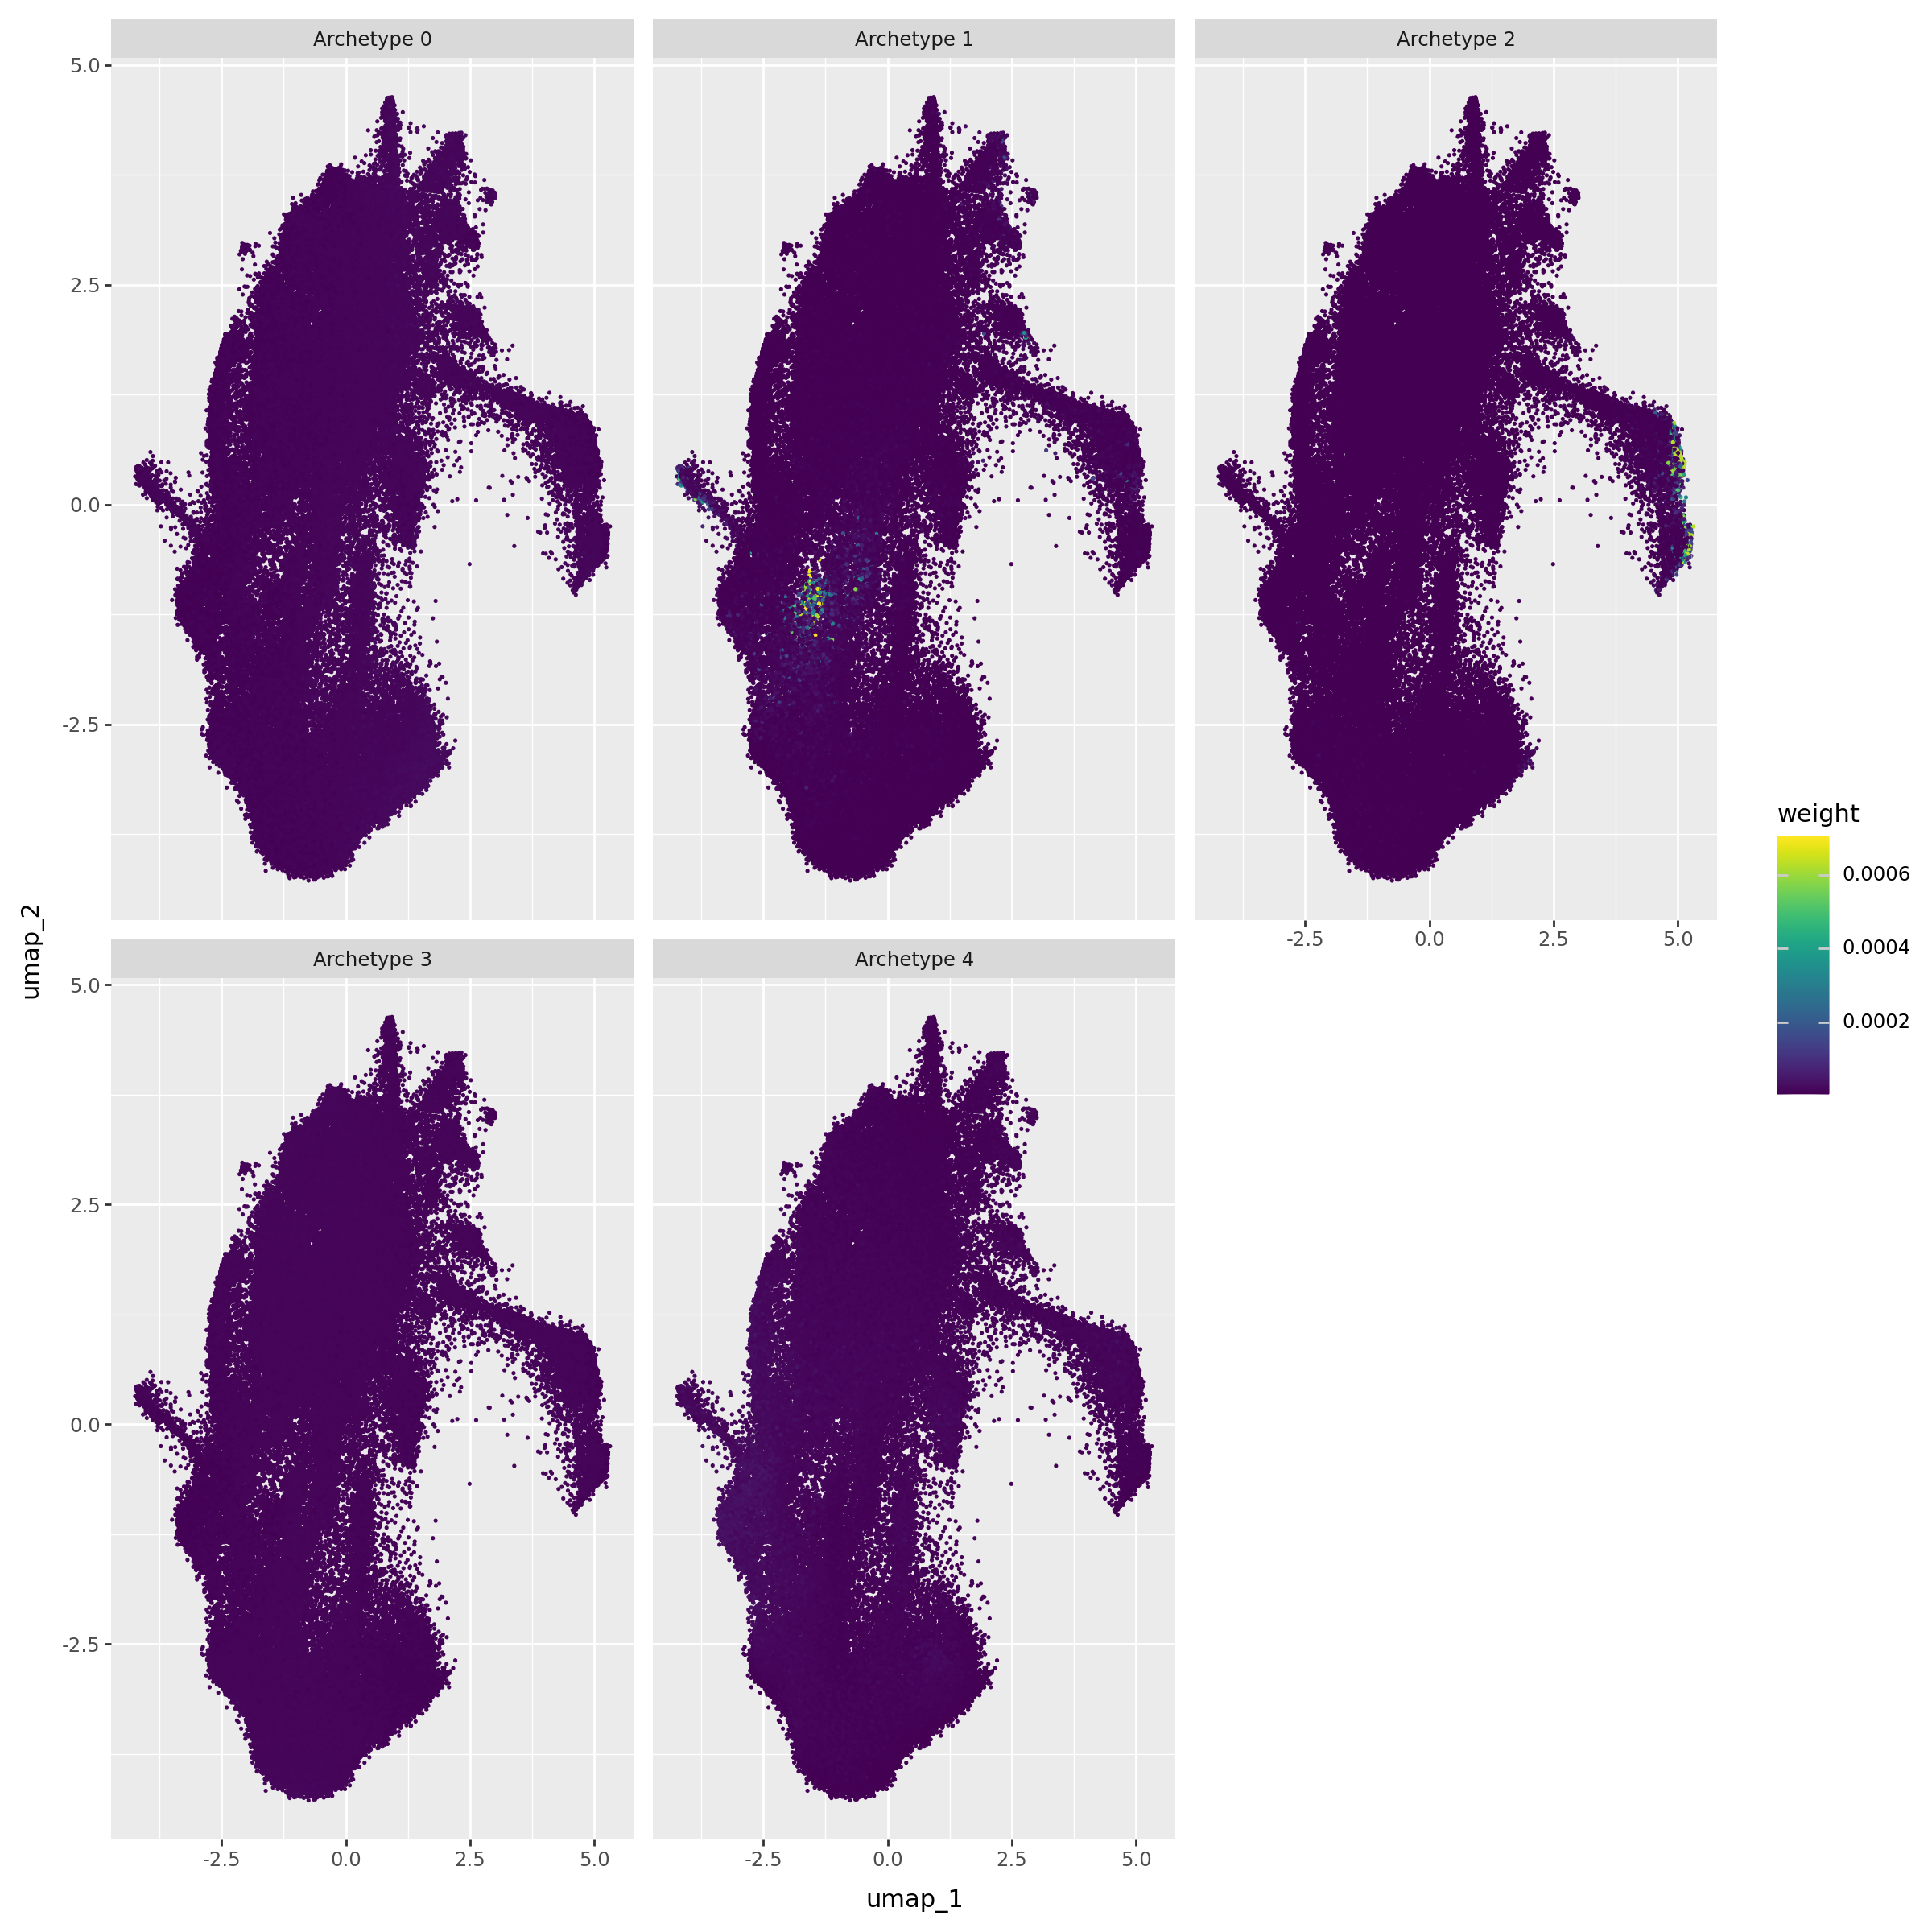

In [58]:
p_umap.save(png_dir / "archetype_weights_umap.png", dpi=150)
p_umap

archetype_group
Archetype_3    40467
Archetype_0    36390
Archetype_4    30428
Archetype_1     9127
Archetype_2     5961
Name: count, dtype: int64


<Axes: title={'center': 'Archetype groups'}, xlabel='UMAP1', ylabel='UMAP2'>

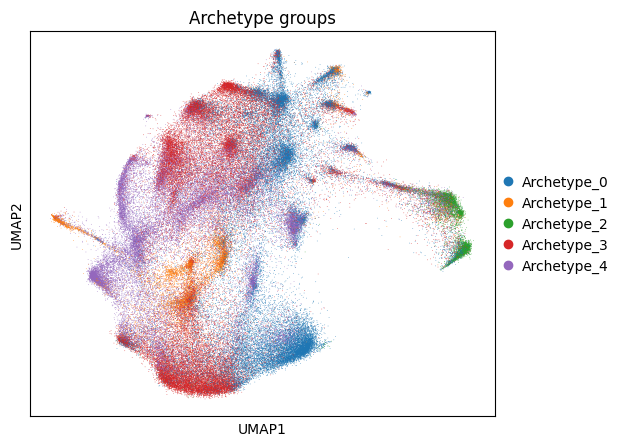

In [64]:
import matplotlib.pyplot as plt

# ── Classify cells by dominant archetype (argmax weight) ─────────────────────
n_archetypes = cell_weights.shape[1]
max_weight   = cell_weights.max(axis=1)
max_arch_idx = cell_weights.argmax(axis=1)

archetype_labels = np.where(
    max_weight > 0,
    np.array([f"Archetype_{i}" for i in max_arch_idx]),
    "Background"
)
adata.obs["archetype_group"] = pd.Categorical(archetype_labels)
print(adata.obs["archetype_group"].value_counts())

# ── UMAP colored by archetype group ──────────────────────────────────────────
arch_cats = [f"Archetype_{i}" for i in range(n_archetypes)]
cmap      = plt.get_cmap("tab10")
palette   = {f"Archetype_{i}": cmap(i) for i in range(n_archetypes)}
palette["Background"] = "#cccccc"
adata.obsm["X_umap"] = adata.obsm["X_pearsonbatchumap"]
fig, ax = plt.subplots(figsize=(6, 5))
sc.pl.umap(adata, color="archetype_group", palette=palette, ax=ax, show=False,
           title="Archetype groups")


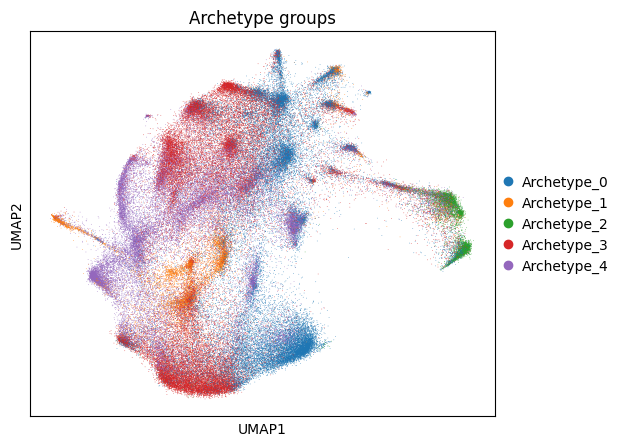

In [65]:
fig.savefig(png_dir / "archetype_group_umap.png", dpi=150, bbox_inches="tight")
fig

In [66]:
# ── Differential expression: each archetype group vs rest ────────────────────
# Exclude Background cells
adata_fg = adata[adata.obs["archetype_group"] != "Background"].copy()
present_groups = [g for g in arch_cats if g in adata_fg.obs["archetype_group"].cat.categories]

sc.tl.rank_genes_groups(
    adata_fg,
    groupby   = "archetype_group",
    groups    = present_groups,
    method    = "wilcoxon",
    reference = "rest",
    use_raw   = False,
    pts       = True,
    key_added = "rank_genes_archetype"
)

# Save per-group DE tables
for grp in present_groups:
    df = sc.get.rank_genes_groups_df(
        adata_fg, group=grp, key="rank_genes_archetype",
        pval_cutoff=None, log2fc_min=None
    )
    df.to_csv(outdir / f"DE_{grp}_vs_rest.csv", index=False)

print("DE results saved.")

DE results saved.


In [69]:
import json
import numpy as np

def _cfg_key(cfg):
    try:
        return f"n{cfg.n_archetypes}"
    except AttributeError:
        return str(cfg)

# ── AA_cell_weights: cells × archetypes — joinable in Seurat via AddMetaData ──
if "AA_cell_weights" in adata.uns:
    for cfg, val in adata.uns["AA_cell_weights"].items():
        arr = np.asarray(val)
        if arr.ndim == 2:
            cols = [f"Archetype_{i}" for i in range(arr.shape[1])]
            pd.DataFrame(arr, index=adata.obs_names, columns=cols).to_csv(
                outdir / f"AA_cell_weights_{_cfg_key(cfg)}.csv"
            )

# ── AA_results: archetype positions per config ────────────────────────────────
if "AA_results" in adata.uns:
    for cfg, res in adata.uns["AA_results"].items():
        tag = _cfg_key(cfg)
        if not isinstance(res, dict):
            continue
        for key, val in res.items():
            try:
                arr = np.asarray(val)
            except Exception:
                continue
            if arr.ndim == 1:
                pd.Series(arr, name=key).to_frame().to_csv(outdir / f"AA_results_{tag}_{key}.csv")
            elif arr.ndim == 2:
                idx  = [f"archetype_{i}" for i in range(arr.shape[0])]
                cols = [f"dim_{i}" for i in range(arr.shape[1])]
                pd.DataFrame(arr, index=idx, columns=cols).to_csv(outdir / f"AA_results_{tag}_{key}.csv")

# ── AA_bootstrap: bootstrap archetype positions ───────────────────────────────
if "AA_bootstrap" in adata.uns:
    for cfg, res in adata.uns["AA_bootstrap"].items():
        tag = _cfg_key(cfg)
        if not isinstance(res, dict):
            continue
        for key, val in res.items():
            try:
                arr = np.asarray(val)
            except Exception:
                continue
            if arr.ndim == 1:
                pd.Series(arr, name=key).to_frame().to_csv(outdir / f"AA_bootstrap_{tag}_{key}.csv")
            elif arr.ndim == 2:
                pd.DataFrame(arr).to_csv(outdir / f"AA_bootstrap_{tag}_{key}.csv")
            elif arr.ndim == 3:
                n_boot, n_arch, n_dim = arr.shape
                midx = pd.MultiIndex.from_product(
                    [range(n_boot), [f"archetype_{i}" for i in range(n_arch)]],
                    names=["bootstrap", "archetype"]
                )
                pd.DataFrame(arr.reshape(-1, n_dim), index=midx).to_csv(
                    outdir / f"AA_bootstrap_{tag}_{key}.csv"
                )

# ── AA_selection_metrics: variance explained + IC per n_archetypes ────────────
if "AA_selection_metrics" in adata.uns:
    metrics = adata.uns["AA_selection_metrics"]
    if isinstance(metrics, pd.DataFrame):
        metrics.to_csv(outdir / "AA_selection_metrics.csv")
    elif isinstance(metrics, dict):
        rows = []
        for cfg, vals in metrics.items():
            row = {"n_archetypes": getattr(cfg, "n_archetypes", str(cfg))}
            if isinstance(vals, dict):
                for k, v in vals.items():
                    try:
                        arr = np.asarray(v)
                        if arr.ndim == 0:
                            row[k] = float(arr)
                    except Exception:
                        pass
            rows.append(row)
        pd.DataFrame(rows).to_csv(outdir / "AA_selection_metrics.csv", index=False)

# ── Strip non-serializable ArchetypeConfig keys before writing h5ad ───────────
adata_save = adata.copy()
for key in ["AA_results", "AA_bootstrap", "AA_cell_weights", "AA_selection_metrics"]:
    adata_save.uns.pop(key, None)

adata_save.write_h5ad(outdir / "archetype_adata.h5ad")
category_enrichment.to_csv(outdir / "category_enrichment.csv")
cluster_enrichment.to_csv(outdir / "cluster_enrichment.csv")
archetype_expression.to_csv(outdir / "archetype_expression.csv")
acts_ulm_est.to_csv(outdir / "pathway_enrichment_est.csv")
acts_ulm_est_p.to_csv(outdir / "pathway_enrichment_pval.csv")
pd.concat(top_processes, names=["archetype"]).to_csv(outdir / "pathway_enrichment_top.csv")

print(f"Results saved to {outdir}")

Results saved to /scratch/pawsey1172/sweng/VisHD/6.3.integrate_tumour_archetype


## Session Info

In [21]:
import session_info2
print(session_info2.session_info(dependencies=True))

plotnine	0.14.5
pandas	2.2.3
requests	2.32.3
scanpy	1.11.2
numpy	2.2.6
squidpy	1.6.5
decoupler	2.0.6
partipy	0.0.1
anndata	0.11.4
----	----
executing	2.2.0
zarr	2.18.7
pyct	0.5.0
prompt_toolkit	3.0.51
ipywidgets	8.1.7
stack-data	0.6.3
attrs	25.3.0
tqdm	4.67.1
geopandas	1.0.1
spatialdata	0.4.0
python-dateutil	2.9.0.post0
scikit-learn	1.6.1
adjustText	1.3.0
debugpy	1.8.14
rich	14.0.0
zipp	3.22.0
joblib	1.5.1
jaraco.text	3.12.1
dask-image	2024.5.3
jupyter_client	8.6.3
ipython	9.2.0
pure_eval	0.2.3
cloudpickle	3.1.1
mizani	0.13.5
pyzmq	26.4.0
docrep	0.3.2
multiscale_spatial_image	2.0.2
platformdirs	4.3.8
crc32c	2.7.1
typing_extensions	4.14.0
pillow	11.2.1
tornado	6.5.1
networkx	3.5
lazy_loader	0.4
colorama	0.4.6
fsspec	2025.5.1
comm	0.2.2
plotly	6.1.2
importlib_metadata	8.7.0
ome-zarr	0.11.1
idna	3.10
asttokens	3.0.0
xarray-schema	0.0.3
pytz	2025.2
numcodecs	0.15.1
imageio	2.37.0
jaraco.functools	4.0.1
datashader	0.18.1
validators	0.35.0
narwhals	1.41.0
statsmodels	0.14.4
shapely	2.1.1
igr